# Machine Learning Powered Cardiovascular Disease Detection Tool

---

### Introduction

Cardiac disease is the leading cause of death worldwide. Distinguishing between different cardiac conditions, especially in patients with overlapping symptoms, is one of the most challenging tasks in clinical medicine.

This project builds a machine learning classifier that distinguishes between four patient classes based on 16 clinical features (9 continuous measurements and 7 categorical symptoms). The dataset is synthetic but generated from peer-reviewed clinical statistics, ensuring the distributions are medically realistic.

The project is divided into four phases:

| Phase | Topic |
|-------|-------|
| 1 | Synthetic Dataset Generator |
| 2 | EDA, Modelling and Evaluation |
| 3 | GUI using Gradio |
| 4 | Report |

---

### Phase 1: Synthetic Dataset Generation

#### Why Synthetic Data?

Real cardiac datasets are either proprietary, small, or heavily de-identified.  
Synthetic data allows this study to:
- Control the degree of **class overlap** (making the classification realistically hard)
- Guarantee **balanced classes** (equal patients per condition)
- Share data **freely** without privacy concerns

The four classes and 16 features used throughout the project are defined below.

### 4 Classes

| Label | Class | Description |
|-------|-------|-------------|
| 0 | Healthy | No diagnosed cardiac condition. |
| 1 | CAD | Coronary Artery Disease. Atherosclerotic plaque in coronary arteries reduces blood flow to the heart muscle. |
| 2 | Arrhythmia | Abnormal electrical rhythm including Atrial Fibrillation, Ventricular Tachycardia, and Tachy/Brady patterns. |
| 3 | Heart Failure | Structural or functional impairment of ventricular filling or ejection. |

### 16 Features

#### Continuous Features

| Feature | Full Name | Unit | Clinical Meaning |
|---------|-----------|------|-----------------|
| **Age** | Patient age | years | Older age increases all cardiac disease risk |
| **BMI** | Body Mass Index | kg/m² | Weight relative to height; ≥30 = obese |
| **Systolic BP** | Systolic Blood Pressure | mmHg | Peak arterial pressure |
| **LDL** | Low Density Lipoprotein cholesterol | mg/dL | Bad cholesterol; drives arterial plaque in CAD |
| **Fasting Glucose** | Blood sugar after ≥8 hr fast | mg/dL | Blood glucose measured after at least 8 hours of fasting |
| **Heart Rate** | Resting pulse | bpm | Resting heart rate in beats per minute |
| **SpO₂** | Peripheral oxygen saturation | % | Percentage of haemoglobin carrying oxygen, measured by pulse oximetry |
| **EF** | Ejection Fraction | % | Percentage of blood pumped out of the left ventricle with each heartbeat |
| **BNP** | B-type Natriuretic Peptide | pg/mL | Hormone released by heart muscle cells under pressure or stretch |

#### Categorical Features

| Feature | Scale | Clinical Meaning |
|---------|-------|-----------------|
| **SOB** | 0=None, 1=Mild, 2=Moderate, 3=Severe | Shortness of Breath at rest or on exertion |
| **Chest Tightness** | 0=None, 1=Non-anginal, 2=Typical angina | Quality of chest discomfort |
| **Smoking** | 0=Never, 1=Light, 2=Moderate, 3=Heavy | Cumulative tobacco exposure |
| **Diabetes** | 0=Normal, 1=Pre-diabetes, 2=Type 2, 3=Type 1 | Glycaemic status; diabetes doubles cardiac risk |
| **Edema** | 0=None, 1=Mild, 2=Severe | Peripheral fluid retention |
| **Palpitations** | 0=None, 1=Occasional, 2=Frequent | Sensation of abnormal heartbeat |
| **ECG** | 0=Normal, 1=Tachy/Brady, 2=AF, 3=VT | Electrocardiogram finding |

---
## Step 1: Import Libraries

The following libraries are imported before any data generation takes place:
- **numpy**: array mathematics and random sampling
- **pandas**: constructing and managing the patient dataframes
- **scipy.stats.truncnorm**: truncated normal distribution for bounded continuous features
- **matplotlib / seaborn**: visualisation of distributions and PCA plots
- **pickle**: serialising metadata for use in Phase 2
- **warnings**: suppressing non-critical output during generation

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm

warnings.filterwarnings('ignore')
np.random.seed(32)

CLASS_NAMES  = ['Healthy', 'CAD', 'Arrhythmia', 'Heart Failure']
CLASS_COLORS = ['#27ae60', '#e74c3c', '#f39c12', '#8e44ad']

CONT_COLS = ['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose',
             'heart_rate', 'spo2', 'ejection_fraction', 'bnp']

CAT_COLS  = ['sob', 'chest_tightness', 'smoking', 'diabetes',
             'edema', 'palpitations', 'ecg']

N = 1500

---
## Step 2: Understanding the Sampling Parameters

Every continuous feature is generated using a normal (bell curve) distribution defined by three values: mean, standard deviation, and the physiological range bounds.

**Mean**  
The most typical (centre) value. Calculated as the midpoint of the published clinical range:  
> **Mean = (Low + High) ÷ 2**

For Healthy age: Mean = (20 + 75) ÷ 2 = 47.5 ≈ **48**

**Standard Deviation (SD)**  
SD controls how spread the values are. It is set so that 95% of generated patients fall inside the published range:  
> **SD = (High − Low) ÷ 4**

For Healthy age: SD = (75 − 20) ÷ 4 = 13.75 ≈ **14**

**Why SD = (High - Low) ÷ 4 achieves 95% coverage:**  
In any normal distribution, 95% of values fall between Mean - 2×SD and Mean + 2×SD:  
- Lower limit = 48 − 2×14 = **20**   
- Upper limit = 48 + 2×14 = **76** 

The remaining 5% of patients fall slightly outside these represent genuine atypical cases present in every real population.

**Worked Example: Healthy BMI (range 18.5–40):**  
- Mean = (18.5 + 40) ÷ 2 = 29.25 ≈ **29** (matches NHANES US adult mean of 29.23)  
- SD = (40 − 18.5) ÷ 4 = 5.375 ≈ **5**

**Why BNP uses Log-Normal instead of Normal:**  
BNP is always positive and right-skewed most patients have low values but a small number have extremely high values. A symmetric bell curve cannot model this shape. Log-normal parameters are derived in log-space:  
> **mu_log = (log(Low) + log(High)) ÷ 2**  
> **sd_log = (log(High) − log(Low)) ÷ 4**

Worked Example: Healthy BNP (range 5–200):  
- log(5) = 1.61, log(200) = 5.30  
- mu_log = (1.61 + 5.30) ÷ 2 = **3.45** → exp(3.45) ≈ 32 pg/mL (median)  
- sd_log = (5.30 − 1.61) ÷ 4 = **0.92**  
- Check: 95% of values between exp(3.45 − 2×0.92) ≈ 5 and exp(3.45 + 2×0.92) ≈ 200

---
## Step 3: Defining the 3 Functions

Three reusable functions encapsulate all generation logic. Every patient in the dataset is produced by calling one of these:

- **`tnorm(mean, sd, lo, hi)`** truncated normal distribution; used for all continuous features except BNP. Truncation at `[lo, hi]` prevents physiologically impossible values from being sampled.
- **`lognorm_trunc(mu_log, sd_log, lo, hi)`** truncated log-normal; used exclusively for BNP because it is always positive and right-skewed.
- **`cat(vals, probs)`** multinomial categorical sampler; used for all seven ordinal-categorical features, drawing from a probability vector sourced from clinical literature.
- **`N = 1500`** number of patients generated per class (4 classes × 1500 = 6000 total).

In [2]:
SEED = 42

def tnorm(mean, sd, lo, hi, n=N):
    a = (lo - mean) / sd
    b = (hi - mean) / sd
    return truncnorm.rvs(a, b, loc=mean, scale=sd, size=n)

def lognorm_trunc(mu_log, sd_log, lo, hi, n=N):
    a = (np.log(lo) - mu_log) / sd_log
    b = (np.log(hi) - mu_log) / sd_log
    lv = truncnorm.rvs(a, b, loc=mu_log, scale=sd_log, size=n)
    return np.exp(lv)

def cat(vals, probs, n=N):
    return np.random.choice(vals, n, p=probs)

---
## Step 4: Generate Class Specific Patient Records

Each class is generated separately using the distributional parameters derived from peer-reviewed clinical statistics. The parameters for each feature (mean, SD, and range) were validated against published population studies.

### Class 0: Healthy

Healthy patients have no diagnosed cardiac condition. Their biomarker profile stays within population-normal ranges: resting heart rate 55 to 100 bpm, SpO₂ 94 to 100%, EF 48 to 76%, and BNP below 200 pg/mL. The categorical features reflect a predominantly low-symptom, low-risk population.

In [3]:
age_H0  = tnorm(48, 14, 20,   75)
bmi_H0  = tnorm(29,  5, 18.5, 40)
sbp_H0  = tnorm(124, 12, 100, 148)
ldl_H0  = tnorm(128, 34, 60,  195)
glc_H0  = tnorm(98,  14, 70,  125)
hr_H0   = tnorm(78,  11, 55,  100)
spo2_H0 = tnorm(97,  1.5, 94, 100)
ef_H0   = tnorm(62,  7,  48,  76)
bnp_H0  = lognorm_trunc(3.45, 0.92, 5, 200)

sob_H0  = cat([0,1,2,3], [0.80,0.20,0.00,0.00])
ct_H0   = cat([0,1,2],   [0.87,0.11,0.02])
sm_H0   = cat([0,1,2,3], [0.65,0.20,0.12,0.03])
dm_H0   = cat([0,1,2,3], [0.66,0.26,0.07,0.01])
ed_H0   = cat([0,1,2],   [0.93,0.06,0.01])
pal_H0  = cat([0,1,2],   [0.38,0.55,0.07])
ecg_H0  = cat([0,1,2,3], [0.80,0.18,0.02,0.00])

print('Healthy generated.')

Healthy generated.


### Class 1: Coronary Artery Disease (CAD)

CAD patients have progressive atherosclerotic plaque narrowing the coronary arteries. Key distinguishing parameters: elevated LDL (mean 175 mg/dL), raised systolic BP (mean 153 mmHg), elevated fasting glucose (mean 145 mg/dL), and typical angina chest tightness (42% probability). BNP is moderately elevated (log-normal, median ~185 pg/mL).

In [4]:
age_H1  = tnorm(61, 11, 40,  82)
bmi_H1  = tnorm(33,  6, 22,  44)
sbp_H1  = tnorm(153, 18, 118, 188)
ldl_H1  = tnorm(175, 45, 85,  265)
glc_H1  = tnorm(145, 33, 80,  210)
hr_H1   = tnorm(80,  16, 48,  112)
spo2_H1 = tnorm(94,   3, 88,  99)
ef_H1   = tnorm(51,  10, 32,  70)
bnp_H1  = lognorm_trunc(5.23, 0.57, 60, 580)

sob_H1  = cat([0,1,2,3], [0.28,0.38,0.24,0.10])
ct_H1   = cat([0,1,2],   [0.20,0.38,0.42])
sm_H1   = cat([0,1,2,3], [0.44,0.22,0.22,0.12])
dm_H1   = cat([0,1,2,3], [0.42,0.18,0.30,0.10])
ed_H1   = cat([0,1,2],   [0.64,0.28,0.08])
pal_H1  = cat([0,1,2],   [0.30,0.50,0.20])
ecg_H1  = cat([0,1,2,3], [0.22,0.42,0.28,0.08])

print('CAD generated.')

CAD generated.


### Class 2: Arrhythmia

The defining feature of this class is heart rate variability. The Arrhythmia class uses SD = 32 bpm (range 38–165 bpm), compared to SD = 11 bpm for Healthy patients, a nearly threefold difference reflecting chaotic electrical conduction. Palpitations are frequent (38% of patients report frequent palpitations) and ECG abnormalities (AF, VT) are substantially more common than in other classes.

In [5]:
age_H2  = tnorm(58, 15, 28,  88)
bmi_H2  = tnorm(31,  6, 20,  42)
sbp_H2  = tnorm(145, 19, 108, 182)
ldl_H2  = tnorm(147, 39, 68,  225)
glc_H2  = tnorm(127, 26, 75,  178)
hr_H2   = tnorm(102, 32, 38,  165)
spo2_H2 = tnorm(93,   3, 86,  99)
ef_H2   = tnorm(54,   9, 35,  72)
bnp_H2  = lognorm_trunc(4.70, 0.85, 20, 600)

sob_H2  = cat([0,1,2,3], [0.30,0.38,0.24,0.08])
ct_H2   = cat([0,1,2],   [0.62,0.28,0.10])
sm_H2   = cat([0,1,2,3], [0.54,0.22,0.18,0.06])
dm_H2   = cat([0,1,2,3], [0.58,0.20,0.18,0.04])
ed_H2   = cat([0,1,2],   [0.74,0.22,0.04])
pal_H2  = cat([0,1,2],   [0.22,0.40,0.38])
ecg_H2  = cat([0,1,2,3], [0.14,0.38,0.28,0.20])

print('Arrhythmia generated.')
print(f'  HR {hr_H2.min():.0f}-{hr_H2.max():.0f}  mean {hr_H2.mean():.0f}  sd {hr_H2.std():.0f}')

Arrhythmia generated.
  HR 38-165  mean 102  sd 28


### Class 3: Heart Failure

Heart Failure patients show the highest fasting glucose (mean 193 mg/dL), lowest SpO₂ (mean 91%), most severe oedema profile (34% severe), and the widest BNP distribution (log-normal, median ~327 pg/mL, range up to 3000 pg/mL). The log-normal parameters (mu_log = 5.79, sd_log = 1.11) reflect the heavy right tail seen in decompensated HF patients.

In [6]:
age_H3  = tnorm(65, 13, 40,  90)
bmi_H3  = tnorm(31,  7, 17,  44)
sbp_H3  = tnorm(146, 23, 100, 192)
ldl_H3  = tnorm(134, 43, 48,  220)
glc_H3  = tnorm(193, 59, 76,  310)
hr_H3   = tnorm(89,  22, 46,  132)
spo2_H3 = tnorm(91,   4, 82,  99)
ef_H3   = tnorm(58,   9, 40,  75)
bnp_H3  = lognorm_trunc(5.79, 1.11, 35, 3000)

sob_H3  = cat([0,1,2,3], [0.20,0.30,0.32,0.18])
ct_H3   = cat([0,1,2],   [0.40,0.42,0.18])
sm_H3   = cat([0,1,2,3], [0.52,0.22,0.18,0.08])
dm_H3   = cat([0,1,2,3], [0.30,0.14,0.42,0.14])
ed_H3   = cat([0,1,2],   [0.28,0.38,0.34])
pal_H3  = cat([0,1,2],   [0.32,0.36,0.32])
ecg_H3  = cat([0,1,2,3], [0.10,0.28,0.32,0.30])

print('Heart Failure generated.')

Heart Failure generated.


---
## Step 5: Assemble the Base Dataset

The four class-specific arrays are now combined into a single dataframe. The steps below:

- **`build_table()`** packages one class's arrays into a pandas DataFrame and assigns the class label string to a `target` column.
- **`pd.concat([t0, t1, t2, t3])`** stacks the four class tables vertically into one 6,000-row table.
- **`.sample(frac=1, random_state=42)`** shuffles all rows so that classes are interleaved rather than appearing in consecutive blocks.
- **`.reset_index(drop=True)`** resets row indices to 0, 1, 2, ... after shuffling.

In [7]:
def build_table(label_str, cont_arrays, cat_arrays):
    d = {}
    for col, arr in zip(CONT_COLS, cont_arrays):
        d[col] = arr
    for col, arr in zip(CAT_COLS, cat_arrays):
        d[col] = arr
    t = pd.DataFrame(d)
    t['target'] = label_str
    return t

t0 = build_table('Healthy',
    [age_H0,bmi_H0,sbp_H0,ldl_H0,glc_H0,hr_H0,spo2_H0,ef_H0,bnp_H0],
    [sob_H0,ct_H0,sm_H0,dm_H0,ed_H0,pal_H0,ecg_H0])

t1 = build_table('CAD',
    [age_H1,bmi_H1,sbp_H1,ldl_H1,glc_H1,hr_H1,spo2_H1,ef_H1,bnp_H1],
    [sob_H1,ct_H1,sm_H1,dm_H1,ed_H1,pal_H1,ecg_H1])

t2 = build_table('Arrhythmia',
    [age_H2,bmi_H2,sbp_H2,ldl_H2,glc_H2,hr_H2,spo2_H2,ef_H2,bnp_H2],
    [sob_H2,ct_H2,sm_H2,dm_H2,ed_H2,pal_H2,ecg_H2])

t3 = build_table('Heart Failure',
    [age_H3,bmi_H3,sbp_H3,ldl_H3,glc_H3,hr_H3,spo2_H3,ef_H3,bnp_H3],
    [sob_H3,ct_H3,sm_H3,dm_H3,ed_H3,pal_H3,ecg_H3])

df_base = pd.concat([t0,t1,t2,t3], ignore_index=True)
df_base = df_base.sample(frac=1, random_state=42).reset_index(drop=True)
print('Base dataset haz been generated.')

Base dataset haz been generated.


The cell below confirms the assembled dataset has the expected shape: 6,000 rows (patients), 17 columns (16 features + target label), and exactly 1,500 records per class.

In [8]:
print(f'Shape   : {df_base.shape}')
print(f'Columns : {list(df_base.columns)}')
print(f'Classes : {df_base.target.value_counts().to_dict()}')
print()

Shape   : (6000, 17)
Columns : ['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose', 'heart_rate', 'spo2', 'ejection_fraction', 'bnp', 'sob', 'chest_tightness', 'smoking', 'diabetes', 'edema', 'palpitations', 'ecg', 'target']
Classes : {'CAD': 1500, 'Arrhythmia': 1500, 'Healthy': 1500, 'Heart Failure': 1500}



---
## Step 6: Add Physiological Enrichment Rules

The base dataset treats each feature as statistically independent within each class. In real patients, however, clinical features are causally connected — elevated BMI drives up blood pressure, reduced ejection fraction triggers BNP release, and so on.

Twelve deterministic enrichment rules are applied additively to the base dataset. No new random noise is introduced; these rules shift existing values based on other feature values in the same patient record. The table below summarises each rule:

| Rule | Relationship | Physiological Basis |
|------|-------------|---------------------|
| R1 | SBP += 0.5 × (BMI − 25) if BMI > 25 | Sympathetic activation from excess adiposity |
| R2 | SBP += 0.4 × (age − 40) if age > 40 | Arterial stiffening ~0.4 mmHg/year above 40 |
| R3 | Glucose += 15 × diabetes_level | Each glycaemic severity step adds ~15 mg/dL |
| R4 | LDL += 12 × smoking_level | Nicotine reduces HDL and promotes LDL oxidation |
| R5 | BNP += 10 × (50 − EF) if EF < 50 | Wall stretch below EF 50% triggers BNP release |
| R6 | BNP += 1.5 × (age − 40) if age > 40 | Age-related cardiac fibrosis raises baseline BNP |
| R7 | BNP += 200 if SOB = 3 AND Edema = 2 | Decompensated HF combined marker |
| R8 | BNP += 8 × (HR − 100) if HR > 100 | Atrial stretch at high HR releases BNP |
| R9 | SpO₂ −= 0.3 × (35 − EF) if EF < 35 | Severe HF causes pulmonary congestion |
| R10 | HR += 10 × (SOB − 1) if SOB ≥ 2 | Respiratory distress triggers tachycardia |
| R11 | Glucose += 3 × (BMI − 30) if BMI > 30 | Visceral fat drives insulin resistance |
| R12 | LDL += 0.8 × (age − 40) if age > 40 | Hepatic VLDL production increases with age |

In [9]:
df_enriched = df_base.copy()

bmi_above_25 = (df_enriched['bmi'] - 25).clip(lower=0)
df_enriched['systolic_bp'] = df_enriched['systolic_bp'] + 0.5 * bmi_above_25

age_above_40 = (df_enriched['age'] - 40).clip(lower=0)
df_enriched['systolic_bp'] = df_enriched['systolic_bp'] + 0.4 * age_above_40

df_enriched['fasting_glucose'] = (df_enriched['fasting_glucose']
                                   + 15 * df_enriched['diabetes'])

df_enriched['ldl'] = df_enriched['ldl'] + 12 * df_enriched['smoking']

ef_deficit = (50 - df_enriched['ejection_fraction']).clip(lower=0)
df_enriched['bnp'] = df_enriched['bnp'] + 10 * ef_deficit

df_enriched['bnp'] = df_enriched['bnp'] + 1.5 * age_above_40

decomp = (df_enriched['sob'] == 3) & (df_enriched['edema'] == 2)
df_enriched['bnp'] = df_enriched['bnp'] + 200 * decomp.astype(int)

hr_above_100 = (df_enriched['heart_rate'] - 100).clip(lower=0)
df_enriched['bnp'] = df_enriched['bnp'] + 8 * hr_above_100

severe_ef_deficit = (35 - df_enriched['ejection_fraction']).clip(lower=0)
df_enriched['spo2'] = df_enriched['spo2'] - 0.3 * severe_ef_deficit

sob_above_1 = (df_enriched['sob'] - 1).clip(lower=0)
df_enriched['heart_rate'] = df_enriched['heart_rate'] + 10 * sob_above_1

bmi_above_30 = (df_enriched['bmi'] - 30).clip(lower=0)
df_enriched['fasting_glucose'] = (df_enriched['fasting_glucose']
                                   + 3 * bmi_above_30)

df_enriched['ldl'] = df_enriched['ldl'] + 0.8 * age_above_40

After applying the enrichment rules, some feature values may be pushed outside physiologically valid bounds (for example, BNP could exceed 5,000 pg/mL). The cell below re-applies boundary constraints using distribution-aware truncation rather than hard clipping, preserving the shape of each feature's distribution while eliminating impossible values.

In [10]:
from scipy.stats import truncnorm
import numpy as np

def truncate_series(s, lo, hi):

    mu = s.mean()
    sd = s.std()

    if sd == 0:
        sd = 1.0

    a = (lo - mu) / sd
    b = (hi - mu) / sd

    mask = (s < lo) | (s > hi)

    if mask.sum() > 0:
        s.loc[mask] = truncnorm.rvs(
            a, b,
            loc=mu,
            scale=sd,
            size=mask.sum()
        )

    return s

def truncate_lognormal_series(s, lo, hi):

    s_safe = s.clip(lower=1e-6)

    log_s = np.log(s_safe)

    mu = log_s.mean()
    sd = log_s.std()

    if sd == 0:
        sd = 1.0

    a = (np.log(lo) - mu) / sd
    b = (np.log(hi) - mu) / sd

    mask = (s < lo) | (s > hi)

    if mask.sum() > 0:

        sampled_logs = truncnorm.rvs(
            a, b,
            loc=mu,
            scale=sd,
            size=mask.sum()
        )

        s.loc[mask] = np.exp(sampled_logs)

    return s

df_enriched['systolic_bp'] = truncate_series(
    df_enriched['systolic_bp'], 75, 225)

df_enriched['fasting_glucose'] = truncate_series(
    df_enriched['fasting_glucose'], 55, 420)

df_enriched['ldl'] = truncate_series(
    df_enriched['ldl'], 20, 350)

df_enriched['spo2'] = truncate_series(
    df_enriched['spo2'], 65, 100)

df_enriched['heart_rate'] = truncate_series(
    df_enriched['heart_rate'], 25, 200)

df_enriched['bnp'] = truncate_lognormal_series(
    df_enriched['bnp'], 3, 5000)

for col in CONT_COLS:
    df_enriched[col] = df_enriched[col].round(1)

---
## Step 7: Compare Base and Enriched Datasets

To decide which dataset to use for modelling, the absolute Pearson correlation between each continuous feature and the class label is computed for both datasets. A higher absolute correlation means that feature carries more discriminative signal for separating the four classes.

The comparison below reveals whether the enrichment rules genuinely improved class separability or merely added correlated noise.

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(CLASS_NAMES)

base_label  = le.transform(df_base['target'])
enr_label   = le.transform(df_enriched['target'])

base_corr = df_base[CONT_COLS].apply(
    lambda col: col.corr(pd.Series(base_label))).abs()
enr_corr  = df_enriched[CONT_COLS].apply(
    lambda col: col.corr(pd.Series(enr_label))).abs()

print('=' * 62)
print('  Feature |Pearson r| with Class  (higher = more signal)')
print('=' * 62)
print(f'  {"Feature":<22} {"Base":>6}  {"Enriched":>8}  Change')
print('  ' + '-' * 52)
for feat in CONT_COLS:
    b = base_corr[feat]
    e = enr_corr[feat]
    arrow = 'higher' if e > b else 'similar'
    print(f'  {feat:<22} {b:>6.3f}  {e:>8.3f}  {arrow}')

  Feature |Pearson r| with Class  (higher = more signal)
  Feature                  Base  Enriched  Change
  ----------------------------------------------------
  age                     0.066     0.066  similar
  bmi                     0.076     0.076  similar
  systolic_bp             0.167     0.141  similar
  ldl                     0.241     0.207  similar
  fasting_glucose         0.356     0.339  similar
  heart_rate              0.219     0.184  similar
  spo2                    0.105     0.105  similar
  ejection_fraction       0.296     0.296  higher
  bnp                     0.331     0.235  similar


**Result and Decision:**  
The enrichment rules did not improve any feature's correlation with the class label. Several key features — LDL, Heart Rate, BNP — actually decreased in correlation after enrichment. The most notable drop is BNP (Δ|r| ≈ −0.10), because the additive rules apply uniformly across all classes, partially obscuring the pre-existing class-specific BNP signal.

Based on this, **the base dataset is selected** for all subsequent EDA and modelling. It preserves higher feature–class correlations, retains natural inter-class overlap zones that make the classification problem realistically hard, and avoids artificially inflated separability that would not generalise to real patient data.

---
## Step 8: Visual Comparison of Feature Distributions

Side-by-side histograms are plotted for each continuous feature, showing the base dataset (left) and enriched dataset (right) for all four classes. This visual check confirms whether the enrichment rules noticeably altered the distribution shapes and class overlap structure.

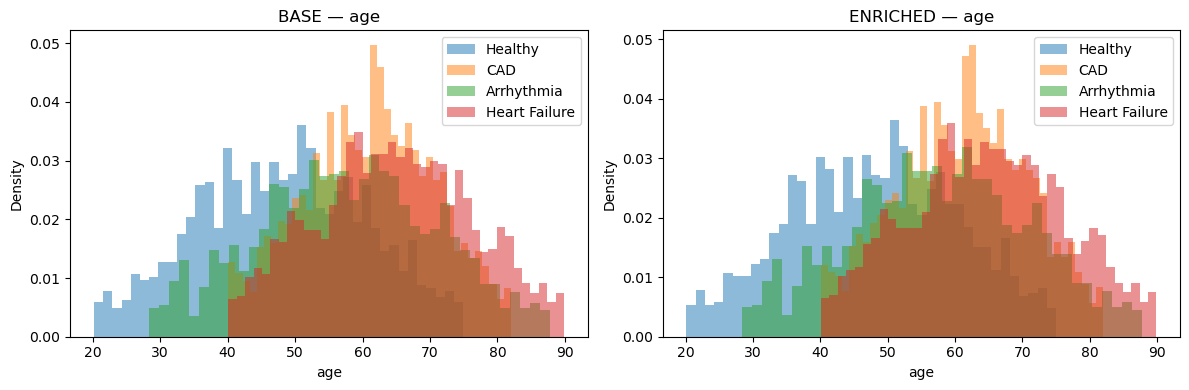

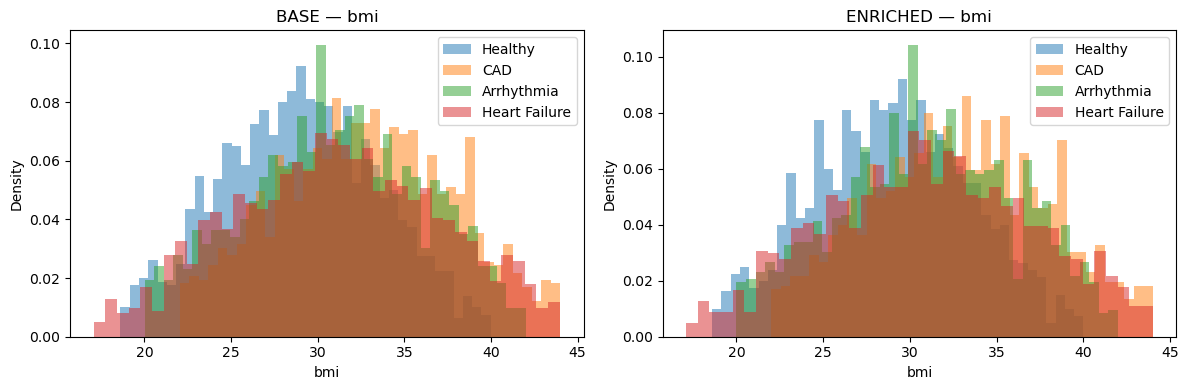

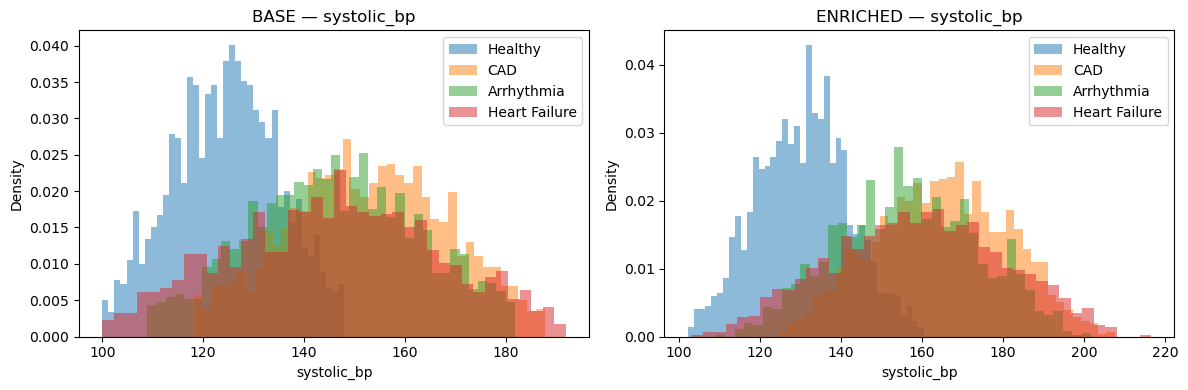

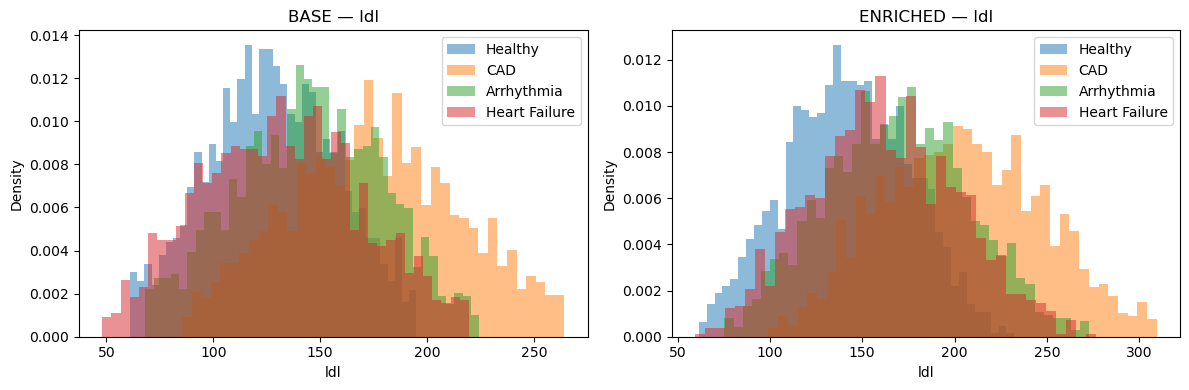

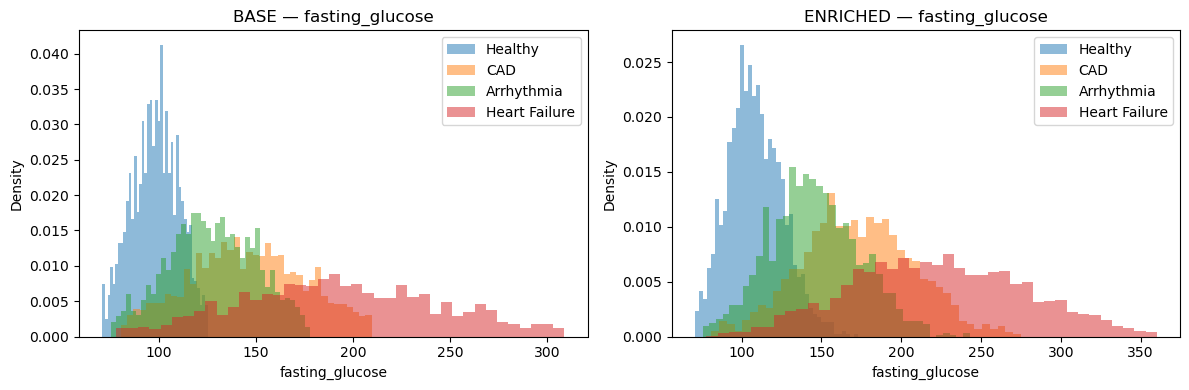

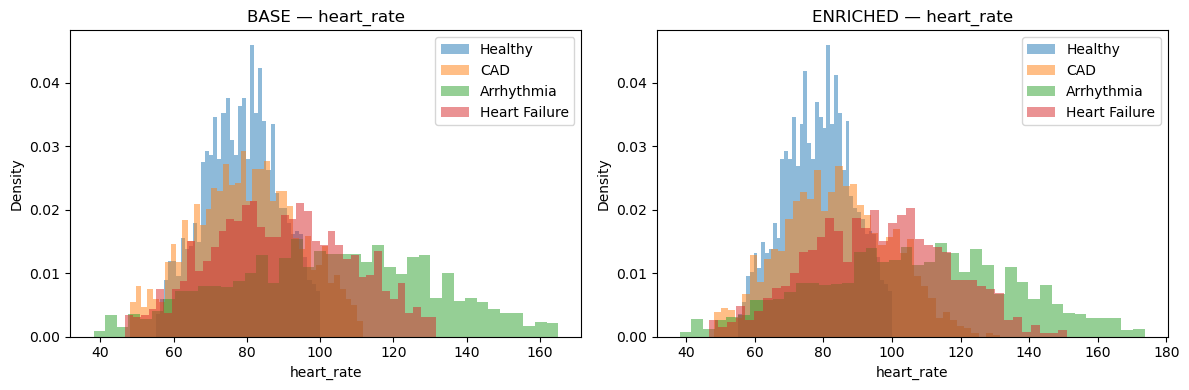

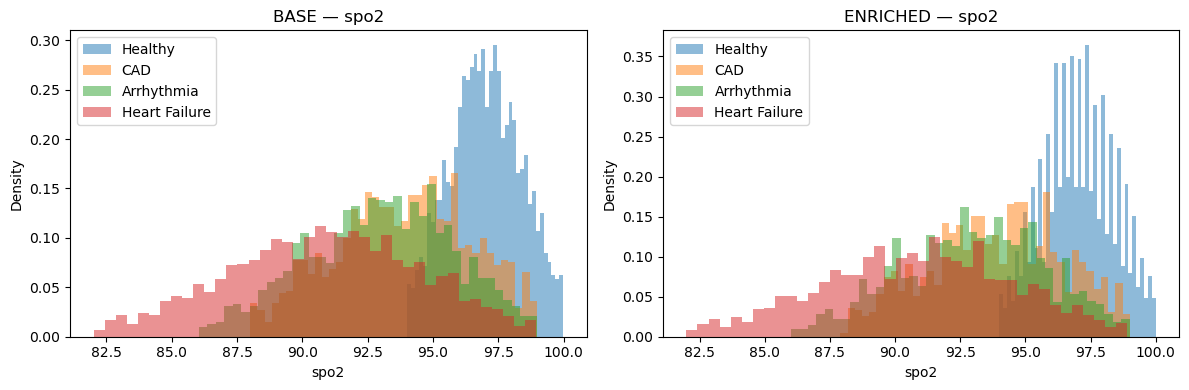

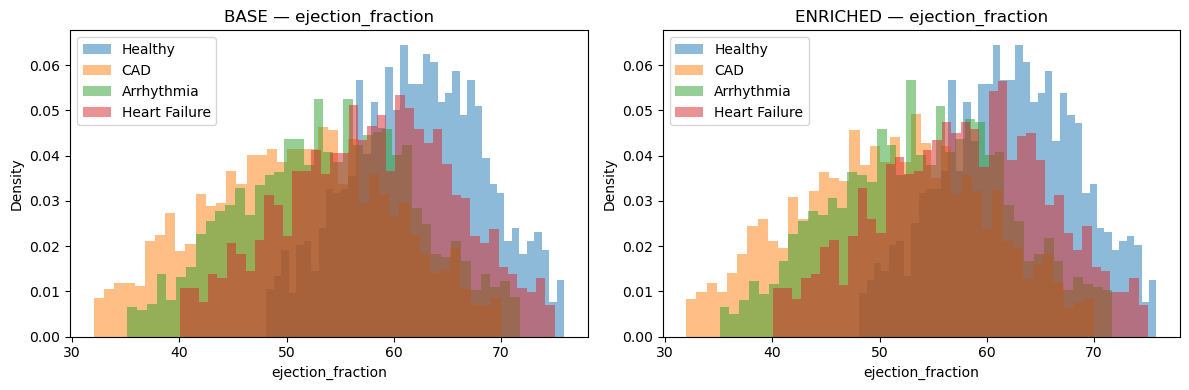

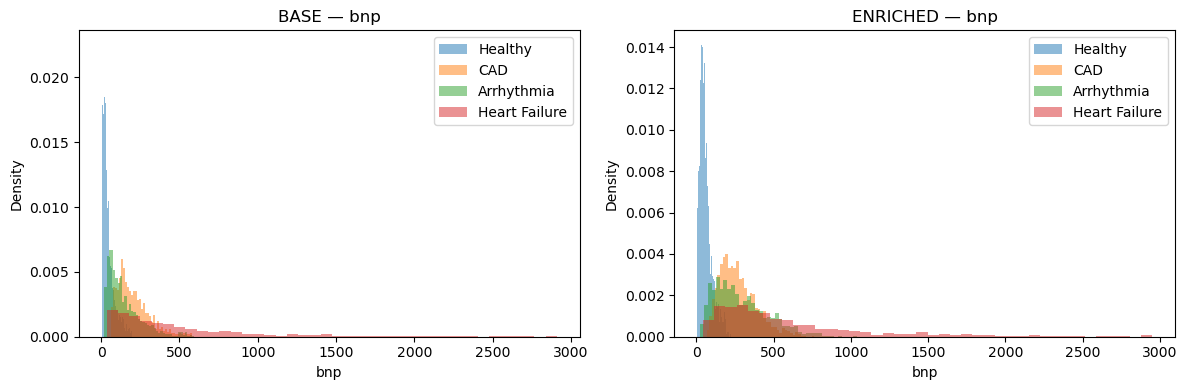

In [12]:
import matplotlib.pyplot as plt

features = CONT_COLS

for feat in features:

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)

    for cls in CLASS_NAMES:
        vals = df_base[df_base['target'] == cls][feat]
        plt.hist(vals, bins=40, alpha=0.5, density=True, label=cls)

    plt.title(f'BASE — {feat}')
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()

    plt.subplot(1, 2, 2)

    for cls in CLASS_NAMES:
        vals = df_enriched[df_enriched['target'] == cls][feat]
        plt.hist(vals, bins=40, alpha=0.5, density=True, label=cls)

    plt.title(f'ENRICHED — {feat}')
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

---
## Step 9: PCA Overlap Analysis

Principal Component Analysis (PCA) projects the nine standardised continuous features into two dimensions for a final visual comparison of class separability. A well-separated scatter plot would suggest the classification problem is too easy and potentially unrealistic; substantial overlap confirms a clinically realistic challenge.

The two-panel plot below shows the PCA scatter for the base dataset (left) and enriched dataset (right).

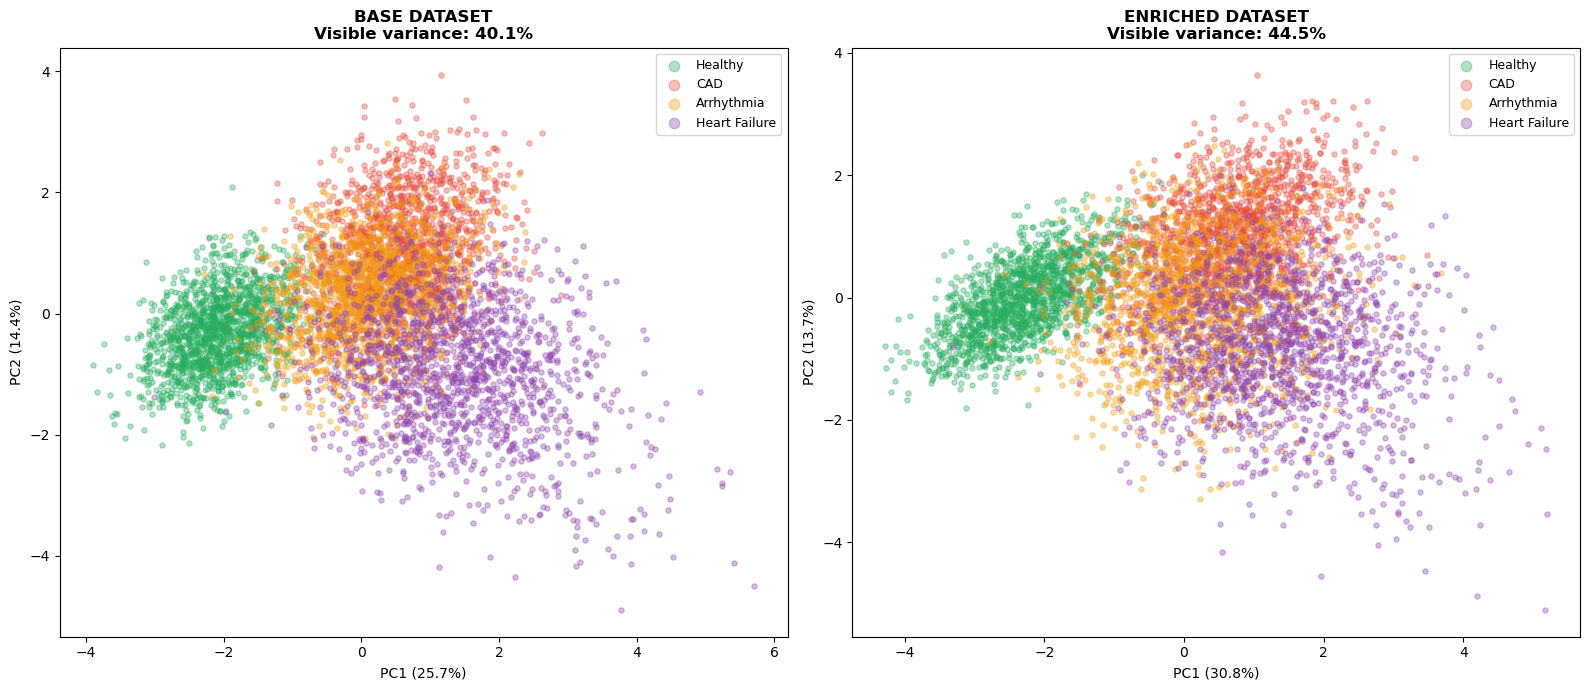

What to look for:
- Too much separation  -> synthetic leakage / unrealistic
- Too much overlap     -> enrichment ineffective
- Moderate overlap     -> more realistic clinical structure


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

datasets = [
    ('BASE DATASET', df_base, axes[0]),
    ('ENRICHED DATASET', df_enriched, axes[1])
]

for title, df_curr, ax in datasets:

    X = df_curr[CONT_COLS].copy()
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)

    var = pca.explained_variance_ratio_ * 100

    for cls, col in zip(CLASS_NAMES, CLASS_COLORS):

        mask = df_curr['target'] == cls

        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            color=col,
            alpha=0.35,
            s=14,
            label=cls
        )

    ax.set_title(
        title + '\nVisible variance: ' + str(round(sum(var), 1)) + '%',
        fontweight='bold'
    )

    ax.set_xlabel(
        'PC1 (' + str(round(var[0], 1)) + '%)'
    )

    ax.set_ylabel(
        'PC2 (' + str(round(var[1], 1)) + '%)'
    )

    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()

print('What to look for:')
print('- Too much separation  -> synthetic leakage / unrealistic')
print('- Too much overlap     -> enrichment ineffective')
print('- Moderate overlap     -> more realistic clinical structure')

**Observation:**  
Both datasets show moderate class overlap in 2D PCA space, which is expected only ~40% of total variance is captured in two components. The Healthy cluster is the most compact; HF patients show the greatest spread. Arrhythmia and CAD overlap substantially with each other and with HF, consistent with their shared blood pressure and BNP elevation.

This confirms the base dataset poses a suitably realistic multi-class classification challenge, and that non-linear ensemble methods will be needed to exploit the full 9-dimensional feature space.

---
## Step 10: Save Datasets and Metadata

The base and enriched datasets are saved as CSV files for use in Phase 2. A metadata pickle file stores the column lists, class names, and colours so that Phase 2 can load them consistently without re-defining constants.

In [14]:
df_enriched.to_csv('cardiac_dataset.csv',     index=False)
df_base.to_csv('cardiac_dataset_base.csv',    index=False)

metadata = {
    'class_names':  CLASS_NAMES,
    'class_colors': CLASS_COLORS,
    'cont_cols':    CONT_COLS,
    'cat_cols':     CAT_COLS,
    'all_cols':     CONT_COLS + CAT_COLS,
    'n_per_class':  N,
}
with open('cardiac_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('Files saved: cardiac_dataset.csv  cardiac_dataset_base.csv  cardiac_metadata.pkl')

Files saved: cardiac_dataset.csv  cardiac_dataset_base.csv  cardiac_metadata.pkl


---
## Phase 1 Summary

This notebook constructed a clinically realistic synthetic patient dataset from scratch using peer-reviewed clinical statistics.

**What was accomplished:**

1. Generated 1,500 patients per class (6,000 total) using truncated normal and log-normal distributions parameterised from published clinical literature
2. Applied twelve physiological enrichment rules encoding known clinical relationships between features
3. Compared base and enriched datasets; the base dataset was selected due to higher feature class correlations and more realistic class overlap
4. Saved both datasets and metadata for use in Phase 2

**Continue with Phase 2: EDA, Modelling, and Evaluation**